# Tutorial de Redes Neuronales Convolucionales para clasificación de imágenes

En este tutorial, aprenderemos cómo utilizar modelos de Redes Neuronales Convolucionales (CNNs) para la clasificación de imágenes utilizando PyTorch. Cubriremos los componentes básicos de una CNN, cómo construir una red y cómo utilizar técnicas para reducir el sobreajuste. Por último, también pondremos a prueba el uso de modelos pre-entrenados de arquitecturas avanzadas de CNNs como lo es ResNet. 

# 1. Preparación del entorno

En tutoriales anteriores exploramos el uso de `torch`, una librería especializada para manipular arreglos de números con estructura de tensor. Para este tutorial, `torch` resulta de gran utilidad, dado el amplio catálogo de funciones, modelos e incluso datasets que contiene. Por otra parte, `sklearn` contiene funciones de cálculo de métricas que nos ayudarán a evaluar el desempeño de nuestros modelos.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import random_split, DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import seaborn as sns
from sklearn.metrics import (
    precision_score, 
    recall_score, 
    f1_score, 
    confusion_matrix, 
    accuracy_score)

## 1.1. Definir equipo en el que se procesarán el modelo y los datos

Debido a que trabajaremos con modelos de aprendizaje profundo, es de gran utilidad contar con una GPU que permita realizar el procesamiento de manera más eficiente. Por lo tanto, antes de iniciar debemos asignar el equipo a usar, idealmente una GPU disponible.

In [2]:
# Declarar device según disponibilidad de GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Equipo disponible para el procesamiento de este tutorial: {device}")

Equipo disponible para el procesamiento de este tutorial: cuda


# 2. Cargar y procesar los datos

## CIFAR10
CIFAR-10 es una base de datos ampliamente utilizada en la investigación de la visión por computadora y el aprendizaje automático, especialmente en tareas de clasificación de imágenes. Este dataset contiene un total de 60,000 imágenes a color de tamaño 32x32 píxeles, organizadas en 10 clases diferentes. Las clases incluyen aviones, automóviles, aves, gatos, ciervos, perros, ranas, caballos, barcos y camiones, cada clase contiene 6,000 imágenes.

Aunque las imágenes son pequeñas y de baja resolución, tienen como ventaja el facilitar experimentos rápidos y pruebas con modelos más simples. Además, CIFAR-10 también es útil para el aprendizaje por transferencia (transfer learning), donde los modelos preentrenados en conjuntos de datos más grandes, como ImageNet, pueden ser ajustados (fine-tuned) en CIFAR-10 para mejorar la precisión.

- **Transformación de los datos:** al cargar los datos aplicamos una serie de transformaciones para preparar los datos antes de procesarlos con nuestra CNN. En particular, ajustaremos las dimensiones de las imágenes a un tamaño fijo de 224x224 pixeles y normalizamos las intensidades de las imágenes a la distribución característica de los datos de CIFAR10.

In [3]:
# Transformaciones para normalizar los datos y convertirlos a tensores
transform = transforms.Compose(
    [transforms.Resize(224),  # Cambiar el tamaño de las imágenes a 224x224 píxeles
     transforms.ToTensor(),
     transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],  # Normalizar 
                          std=[0.2023, 0.1994, 0.2010])])

# Cargar los datos de entrenamiento y prueba
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
classes = trainset.classes

# Combinar los datasets de entrenamiento y prueba
full_dataset = torch.utils.data.ConcatDataset([trainset, testset])

# Definir tamaños para entrenamiento, validación y prueba
full_size = len(full_dataset)
train_size = int(0.7 * full_size)
val_size = int(0.15 * full_size)
test_size = full_size - train_size - val_size

# Dividir el conjunto de datos en entrenamiento, validación y prueba
trainset, valset, testset = random_split(full_dataset, [train_size, val_size, test_size])

# Crear DataLoaders para cada conjunto de datos
trainloader = DataLoader(trainset, batch_size=32, shuffle=True)
valloader = DataLoader(valset, batch_size=32, shuffle=False)
testloader = DataLoader(testset, batch_size=32, shuffle=False)

# Verificar las longitudes de los datasets
print(f'Tamaño del conjunto de entrenamiento: {len(trainset)}')
print(f'Tamaño del conjunto de validación: {len(valset)}')
print(f'Tamaño del conjunto de prueba: {len(testset)}')
del trainset, valset, testset

print(f'Clases dentro del dataset de CIFAR10: {classes}')
del full_dataset

Files already downloaded and verified
Files already downloaded and verified
Tamaño del conjunto de entrenamiento: 42000
Tamaño del conjunto de validación: 9000
Tamaño del conjunto de prueba: 9000
Clases dentro del dataset de CIFAR10: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


# 2.1. Visualizar ejemplos de la base de datos

A continuación vemos ejemplos aleatorios de cada una de las 10 clases disponibles en CIFAR10.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


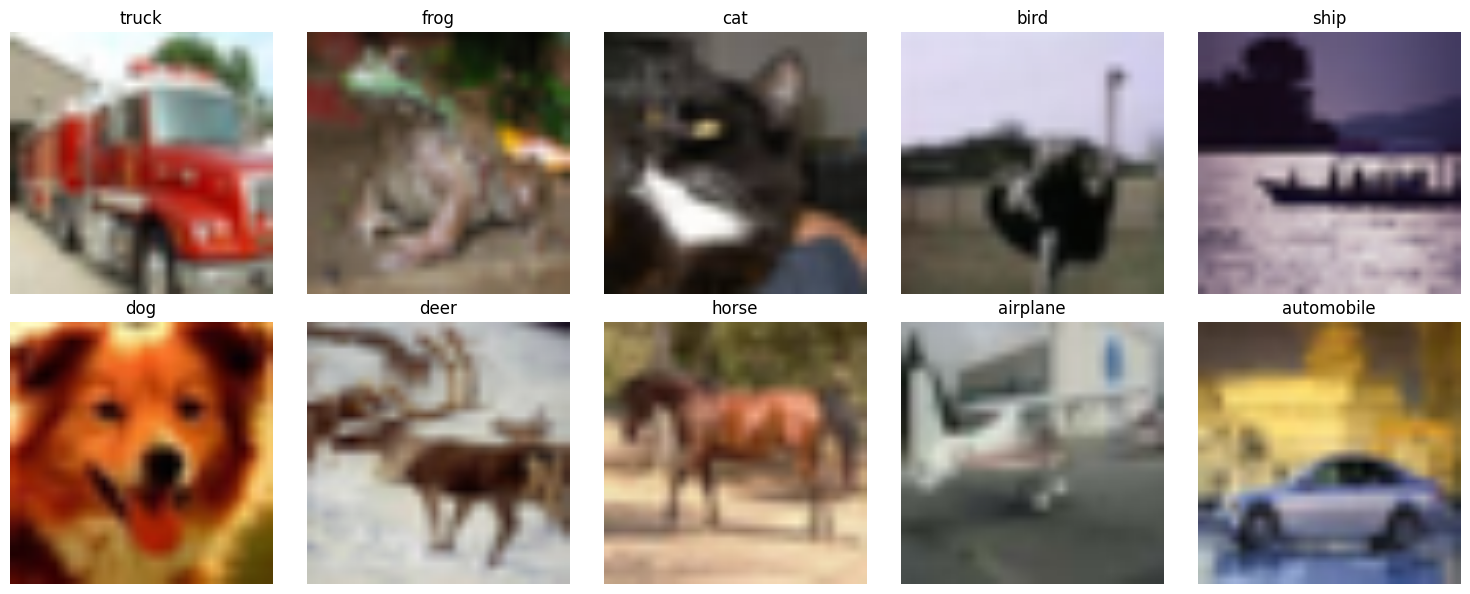

In [4]:
# Función para denormalizar las imágenes (revertir la normalización)
def denormalize(tensor, mean, std):
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return tensor

class_examples = {}
# Buscar ejemplos aleatorios para cada clase
for images, labels in testloader:
    label = labels[0].item()
    class_name = classes[label]
    if class_name not in class_examples.keys():
        class_examples[class_name] = images[0]

# Crear subplots para visualizar las imágenes
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

# Mostrar una imagen por cada clase en el subplot
for idx, (class_name, img) in enumerate(class_examples.items()):
    img2 = denormalize(img, mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])
    img2 = np.transpose(img2.numpy(), (1, 2, 0))  # Cambiar la forma a HWC para matplotlib
    axes[idx].imshow(img2)
    axes[idx].set_title(class_name, fontsize='large')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

# 3. Definir la arquitectura de la CNN
En esta sección construimos una red convolucional sencilla compuesta por 2 capas convolucionales, cada una seguida de una capa de pooling, y 3 capas completamente conectadas que terminan en una salida del tamaño del conteo de clases en nuestra base de datos. Esta última especificación es de gran importancia al construir un modelo de clasificación, pues es lo que permite obtener una probabilidad asociada a cada categoría para finalmente presentar una predicción asociada a la imagen de entrada.

In [5]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes, dropout=0.3):
        super(SimpleCNN, self).__init__()
        
        # Definir las capas convolucionales
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)  # 3 canales de entrada (RGB), 16 filtros, tamaño de kernel 3x3
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1) # 16 canales de entrada, 32 filtros, tamaño de kernel 3x3
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1) # 32 canales de entrada, 64 filtros, tamaño de kernel 3x3
        self.conv4 = nn.Conv2d(64, 128, 3, padding=1) # 64 canales de entrada, 128 filtros, tamaño de kernel 3x3
        self.conv5 = nn.Conv2d(128, 256, 3, padding=1) # 128 canales de entrada, 256 filtros, tamaño de kernel 3x3
        self.conv6 = nn.Conv2d(256, 512, 3, padding=1) # 256 canales de entrada, 512 filtros, tamaño de kernel 3x3
        
        # Definir las capas de pooling
        self.pool = nn.MaxPool2d(2, 2) # Max pooling con tamaño de ventana 2x2
        
        # Definir las capas completamente conectadas
        self.fc1 = nn.Linear(512 * 9, 256) # 512 canales de entrada, 256 salidas
        self.fc2 = nn.Linear(256, num_classes) # 256 entradas, num_classes salidas (clases)
        
        # Añadir dropout
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x))) 
        x = self.pool(F.relu(self.conv3(x))) 
        x = self.pool(F.relu(self.conv4(x)))
        x = self.pool(F.relu(self.conv5(x))) 
        x = self.pool(F.relu(self.conv6(x))) 
        
        x = x.view(x.size(0), -1) # Aplanar tensor
        
        x = F.relu(self.fc1(x)) # Primera capa completamente conectada + ReLU
        x = self.dropout(x) # Dropout
        x = self.fc2(x) # Segunda capa completamente conectada (salida)
        
        return x


## Declarar modelo

Una vez planeamos la arquitectura del modelo lo declaramos considerando los parámetros necesarios (en este caso, el número de clases y la probabilidad de dropout deseada). 

In [6]:
dropout = 0.5
model = SimpleCNN(num_classes=len(classes), dropout=dropout).to(device)
print("CNN declarada en la variable 'model'")

CNN declarada en la variable 'model'


# 4. Definir la función de pérdida y el optimizador
Te invitamos a experimentar con distintos valores para los siguientes parámetros y evaluar cómo afectan el entrenamiento y el desempeño del modelo.

In [7]:
# Definir criterio de pérdida: teniendo en cuenta que estamos tratando una tarea de clasificación, usamos Cross Entropy Loss.
criterion = nn.CrossEntropyLoss()
# Definir optimizador
learning_rate = 0.0005
momentum = 0.9
optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum)

# 5. Ciclo de entrenamiento
La función de `train_model` presenta el ciclo de entrenamiento desde el recorrido por el dataloader completo y la obtención de las predicciones correspondientes a cada batch para calcular la pérdida del modelo, hasta el proceso de validación. Durante la validación evaluamos de manera preliminar la habilidad de clasificación del modelo para con ello poder analizar la posible presencia de overfitting y asegurarnos de guardar los pesos correspondientes al estado óptimo de la red.

In [8]:
def train_model(model, epochs, train_dataloader, valid_dataloader, loss_criterion, optimizer, device):

    # Listas para registrar el loss y el accuracy a lo largo del ciclo de entrenamiento, incluyendo validación
    train_losses, train_accuracies = [], []
    valid_losses, valid_accuracies = [], []
    
    # Inicializar variable para comparar desempeño del modelo durante validación entre épocas
    best_val_accuracy = 0.0
    best_model_wts = None
    
    model.to(device)
    for epoch in range(epochs): 
        model.train()  # Nos aseguramos de que el modelo esté en modo de entrenamiento
        
        # Variables para registrar desempeño del modelo a lo largo de toda la época
        batch_loss = 0.0
        correct_train = 0
        total_train = 0

        # Iterar sobre el conjunto de entrenamiento
        for data in tqdm(train_dataloader):
            inputs, labels = data[0].to(device), data[1].to(device)  # Obtener los inputs y labels del batch actual
            optimizer.zero_grad()  # Limpiar los gradientes de los parámetros optimizados
            outputs = model(inputs)  # Hacer una pasada hacia adelante (forward pass)
            loss = loss_criterion(outputs, labels)  # Calcular la pérdida entre las predicciones y las etiquetas reales
            loss.backward()  # Hacer la pasada hacia atrás o retropropagación (backward pass) para calcular los gradientes
            optimizer.step()  # Actualizar los parámetros del modelo usando los gradientes calculados
            
            batch_loss += loss.item()  # Acumular la pérdida del batch actual
            _, predicted = torch.max(outputs.data, 1)  # Obtener las predicciones del modelo tomando la clase con mayor probabilidad para cada dato
            total_train += labels.size(0)  # Incrementar el conteo total de muestras procesadas
            correct_train += (predicted == labels).sum().item()  # Contar las predicciones correctas

        train_loss = batch_loss / len(train_dataloader)  # Calcular la pérdida media para la época
        train_accuracy = 100 * correct_train / total_train  # Calcular la precisión para la época

        # Validar el modelo al final de la época
        model.eval()  # Poner el modelo en modo de evaluación
        val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():  # Desactivar el cálculo de gradientes para la validación
            for data in tqdm(valid_dataloader):
                inputs, labels = data[0].to(device), data[1].to(device) # Obtener los inputs y labels del batch de validación
                outputs = model(inputs)  # Hacer una pasada hacia adelante (forward pass)
                loss = loss_criterion(outputs, labels)  # Calcular la pérdida entre las predicciones y las etiquetas reales
                val_loss += loss.item()  # Acumular la pérdida del batch de validación
                _, predicted = torch.max(outputs.data, 1)  # Obtener las predicciones del modelo
                total_val += labels.size(0)  # Incrementar el conteo total de muestras procesadas
                correct_val += (predicted == labels).sum().item()  # Contar las predicciones correctas

        val_loss = val_loss / len(valid_dataloader)  # Calcular la pérdida media para el conjunto de validación
        val_accuracy = 100 * correct_val / total_val  # Calcular la precisión para el conjunto de validación

        # Imprimir estadísticas por época
        print(f'Epoch [{epoch + 1}/{epochs}]\n'
              f'Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%\n'
              f'Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%')
        
        # Guardar el modelo si mejora la precisión en el conjunto de validación
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            torch.save(model.state_dict(), f'best_model.pth')
            best_model_wts = model.state_dict()
            print(f'** Model checkpoints from epoch {epoch+1} with accuracy of {val_accuracy:.2f}% saved in "best_model.pth" **')
        
        print('---'*30)
        # Registrar desempeño de la época
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        valid_losses.append(val_loss)
        valid_accuracies.append(val_accuracy)

    print('Finished Training')
    # Cargar los mejores pesos del modelo
    model.load_state_dict(best_model_wts)

    return train_losses, train_accuracies, valid_losses, valid_accuracies, model

In [9]:
def plot_results(losses: tuple, accuracies: tuple, titles: list):
    """
    Esta función recibe los valores de pérdida y de accuracy registrados durante el entrenamiento y la validación
    para presentar el gráfico de estos valores a lo largo de las épocas.
    """

    epochs = range(1, len(losses[0]) + 1)
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))

    # Plot losses
    for set in range(len(losses)):
        axs[0].plot(epochs, losses[set], label=titles[set], marker='o')
    axs[0].set_title('Loss')
    axs[0].set_xlabel('Epochs')
    axs[0].set_ylabel('Loss')
    axs[0].legend()

    # Plot accuracies
    for set in range(len(losses)):
        axs[1].plot(epochs, accuracies[set], label=titles[set], marker='o')
    axs[1].set_title('Accuracy')
    axs[1].set_xlabel('Epochs')
    axs[1].set_ylabel('Accuracy (%)')
    axs[1].legend()

    plt.tight_layout()
    plt.show()

### Entrenar modelo y retornar registro del proceso

In [9]:
# Establecer cantidad de épocas de entrenamiento
num_epochs = 10 
print(device)
# Entrenar modelo
train_output = train_model(
    model=model, 
    epochs=num_epochs, 
    train_dataloader=trainloader,
    valid_dataloader=valloader, 
    loss_criterion=criterion, 
    optimizer=optimizer, 
    device=device
    )

train_losses, train_accuracies, valid_losses, valid_accuracies, model = train_output
model = model.to(device)
plot_results((train_losses, valid_losses), (train_accuracies, valid_accuracies), titles = ['Training', 'Validation'])

cuda


100%|██████████| 282/282 [02:41<00:00,  1.75it/s]


Epoch [1/10]
Train Loss: 2.3019, Train Accuracy: 11.39%
Validation Loss: 2.3010, Validation Accuracy: 13.21%
** Model checkpoints from epoch 1 with accuracy of 13.21% saved in "best_model.pth" **
------------------------------------------------------------------------------------------


100%|██████████| 282/282 [02:47<00:00,  1.69it/s]


Epoch [2/10]
Train Loss: 2.2857, Train Accuracy: 15.34%
Validation Loss: 2.1746, Validation Accuracy: 22.46%
** Model checkpoints from epoch 2 with accuracy of 22.46% saved in "best_model.pth" **
------------------------------------------------------------------------------------------


...

100%|██████████| 282/282 [02:31<00:00,  1.86it/s]


Epoch [9/10]
Train Loss: 1.1832, Train Accuracy: 58.55%
Validation Loss: 1.1596, Validation Accuracy: 59.17%
** Model checkpoints from epoch 9 with accuracy of 59.17% saved in "best_model.pth" **
------------------------------------------------------------------------------------------


100%|██████████| 282/282 [02:43<00:00,  1.73it/s]


Epoch [10/10]
Train Loss: 1.1098, Train Accuracy: 61.15%
Validation Loss: 1.1110, Validation Accuracy: 60.72%
** Model checkpoints from epoch 10 with accuracy of 60.72% saved in "best_model.pth" **
------------------------------------------------------------------------------------------
Finished Training


NameError: name 'plot_results' is not defined

# 6. Evaluación de modelo entrenado
Una vez hemos entrenado nuestro modelo debemos observar su comportamiento con datos nunca antes vistos, por lo que evaluamos con el conjunto de datos de test. La siguiente función recorre el dataloader de evaluación completo y presenta el desempeño de la red considerando métricas como el accuracy, la precisión, la cobertura y la medida F1 de las predicciones. Además, se presenta la matriz de confusión para poder diferenciar con mayor claridad el desempeño en las clases individuales.

In [ ]:

def test_model(model, test_dataloader):
    model.eval()  # Poner el modelo en modo evaluación
    all_labels = []
    all_preds = []

    with torch.no_grad():  # Desactivar el cálculo de gradientes para la evaluación
        for data in tqdm(test_dataloader):
            inputs, labels = data[0].to(device), data[1].to(device)  
            outputs = model(inputs)  
            _, predicted = torch.max(outputs.data, 1)  # Obtener las predicciones del modelo
            
            all_labels.extend(labels.cpu().numpy())  # Almacenar etiquetas reales
            all_preds.extend(predicted.cpu().numpy())  # Almacenar predicciones

    # Calcular las métricas
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')
    conf_matrix = confusion_matrix(all_labels, all_preds)

    # Imprimir las métricas
    print(f'Accuracy: {accuracy:.2f}')
    print(f'Precision: {precision:.2f}')
    print(f'Recall: {recall:.2f}')
    print(f'F1 Score: {f1:.2f}')
    print('Confusion Matrix:')
    
    # Plotear matriz de confusión
    plt.figure()
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predictions')
    plt.ylabel('True classes')
    plt.title('Confusion Matrix')
    plt.show()

### Evaluar modelo entrenado de CNN

In [ ]:
test_model(model=model, test_dataloader=testloader)

# 6.1. Visualizar predicciones del modelo entrenado

In [ ]:
# Crear subplots para visualizar las imágenes
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

# Desactivar gradientes para la inferencia
with torch.no_grad():
    for idx, (class_name, img) in enumerate(class_examples.items()):
        img_batch = img.unsqueeze(0) 
        output = model(img_batch.to(device))  # Obtener la predicción del modelo
        _, predicted = torch.max(output, 1)  
        predicted_class = classes[predicted.item()]
        img2 = np.transpose(img.numpy(), (1, 2, 0))  
        axes[idx].imshow(img2)
        axes[idx].set_title(f'True: {class_name}\nPred: {predicted_class}', fontsize='large')
        axes[idx].axis('off')

plt.tight_layout()
plt.show()